# 03 — Process feature dataset + EDA

Đọc `data/churn_feature_dataset.csv` (output notebook 02), làm sạch / mã hóa về numeric, xuất processed dataset, rồi EDA (kèm missing value).

| Bước | Việc làm |
|---|---|
| Drop | Cột ID dư, nhãn phụ (case breakdown), cột hằng / trùng ý |
| Encode | `gender`, `region`, `city`, `subscription_tier`, `auto_renew`, `snapshot_month` → numeric |
| Missing | Báo cáo trước/sau; impute có kiểm soát + flag missing khi hữu ích |
| Export | `data/churn_feature_dataset_processed.parquet` + `.csv` |
| EDA | Phân bố nhãn, missing, mô tả, tương quan với `churn_30d` |

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = None
for _p in [Path.cwd(), Path.cwd().parent, Path.cwd() / "notebooks"]:
    cand = _p if (_p / "data").exists() else (_p.parent if (_p.parent / "data").exists() else None)
    if cand is not None and (cand / "data" / "churn_feature_dataset.csv").exists():
        PROJECT_ROOT = cand.resolve()
        break
if PROJECT_ROOT is None:
    PROJECT_ROOT = Path.cwd().resolve()

INPUT_CSV = PROJECT_ROOT / "data" / "churn_feature_dataset.csv"
OUTPUT_PARQUET = PROJECT_ROOT / "data" / "churn_feature_dataset_processed.parquet"
OUTPUT_CSV = PROJECT_ROOT / "data" / "churn_feature_dataset_processed.csv"
TARGET = "churn_30d"

print("PROJECT_ROOT", PROJECT_ROOT)
print("INPUT", INPUT_CSV)

PROJECT_ROOT C:\Homework\AI-Intern\temp
INPUT C:\Homework\AI-Intern\temp\data\churn_feature_dataset.csv


## 1. Load raw feature dataset

In [4]:
raw = pd.read_csv(INPUT_CSV)
print("shape", raw.shape)
print(raw.dtypes.to_string())
raw.head()

shape (166084, 49)
customer_id                           int64
snapshot_month                       object
snapshot_date                        object
churn_30d                             int64
churn_60d                             int64
churn_case1_30d                       int64
churn_case2_30d                       int64
churn_case2a_30d                      int64
churn_case2b_30d                      int64
days_since_last_login               float64
days_since_last_usage_event         float64
days_since_last_order               float64
days_since_last_activity            float64
total_active_days_30d               float64
total_active_days_60d               float64
total_active_days_90d               float64
num_usage_events_30d                float64
num_usage_events_60d                float64
avg_session_duration_30d            float64
total_session_time_30d              float64
event_type_diversity_30d            float64
usage_trend_30d                     float64
session_durat

,customer_id,snapshot_month,snapshot_date,churn_30d,churn_60d,churn_case1_30d,churn_case2_30d,churn_case2a_30d,churn_case2b_30d,days_since_last_login,days_since_last_usage_event,days_since_last_order,days_since_last_activity,total_active_days_30d,total_active_days_60d,total_active_days_90d,num_usage_events_30d,num_usage_events_60d,avg_session_duration_30d,total_session_time_30d,event_type_diversity_30d,usage_trend_30d,session_duration_trend,activity_slope_3m,is_declining_engagement,reactivation_flag,num_usage_events_30d_lag1m,days_since_last_activity_lag1m,num_usage_events_roll3m_sum,avg_session_duration_roll3m_mean,orders_roll3m_sum,num_tickets_90d,avg_csat_score,has_unresolved_ticket,payments_success_rate,orders_last_30d,orders_last_90d,avg_spend_to_date_per_month,tenure_days,age,gender,region,city,subscription_tier,is_paid_tier,auto_renew,account_status,has_marketing_click_30d,open_rate_30d
0,1,2025-03,2025-03-31,0,0,0,0,0,0,7.0,7.0,7.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0,0,NaN,NaN,0.0,0.0,0.0,0.0,NaN,0,NaN,0.0,0.0,0.000000e+00,7,33.9,M,Mien Nam,Ho Chi Minh,Plus,1,True,Active,0,0.0
1,1,2025-04,2025-04-30,0,0,0,0,0,0,37.0,37.0,10.0,10.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0,0,0.0,7.0,0.0,0.0,2.0,1.0,NaN,0,0.750000,2.0,2.0,3.093243e+06,37,33.9,M,Mien Nam,Ho Chi Minh,Plus,1,True,Active,0,NaN
2,1,2025-05,2025-05-31,0,0,0,0,0,0,68.0,68.0,41.0,41.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0,0,0.0,10.0,0.0,0.0,2.0,1.0,NaN,0,0.800000,0.0,2.0,1.683088e+06,68,34.0,M,Mien Nam,Ho Chi Minh,Plus,1,True,Active,0,0.0
3,1,2025-06,2025-06-30,0,0,0,0,0,0,98.0,98.0,2.0,2.0,1.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0,1,0.0,41.0,0.0,0.0,3.0,1.0,NaN,0,0.857143,1.0,3.0,1.167857e+06,98,34.1,M,Mien Nam,Ho Chi Minh,Plus,1,True,Active,0,0.0
4,1,2025-07,2025-07-31,0,0,0,0,0,0,129.0,129.0,24.0,24.0,1.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0,0,0.0,2.0,0.0,0.0,2.0,0.0,NaN,0,0.857143,1.0,3.0,1.143256e+06,129,34.2,M,Mien Nam,Ho Chi Minh,Plus,1,True,Active,0,0.5


## 2. Missing value — trước khi xử lý

In [5]:
def missing_report(df: pd.DataFrame) -> pd.DataFrame:
    miss = df.isna().sum()
    pct = df.isna().mean() * 100
    out = pd.DataFrame({"n_missing": miss, "pct_missing": pct.round(2), "dtype": df.dtypes.astype(str)})
    return out.loc[out["n_missing"] > 0].sort_values("pct_missing", ascending=False)


miss_before = missing_report(raw)
print("cột có missing:", len(miss_before), "/", raw.shape[1])
miss_before

cột có missing: 8 / 49


,n_missing,pct_missing,dtype
session_duration_trend,133096,80.14,float64
avg_csat_score,129876,78.20,float64
open_rate_30d,69138,41.63,float64
payments_success_rate,41881,25.22,float64
subscription_tier,14148,8.52,object
auto_renew,14148,8.52,object
days_since_last_activity_lag1m,9724,5.85,float64
num_usage_events_30d_lag1m,9724,5.85,float64


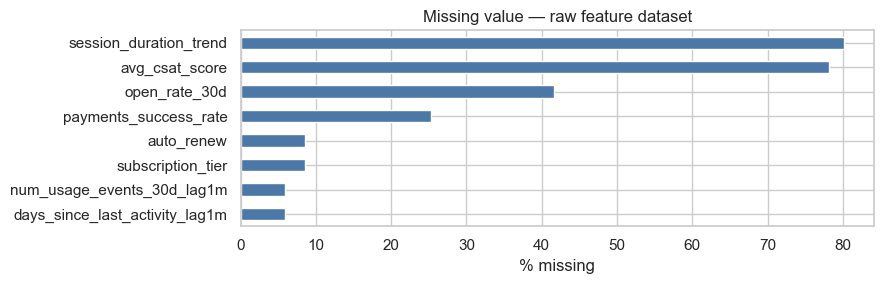

In [6]:
if len(miss_before):
    fig, ax = plt.subplots(figsize=(9, max(3, 0.35 * len(miss_before))))
    miss_before["pct_missing"].sort_values().plot(kind="barh", ax=ax, color="#4C78A8")
    ax.set_xlabel("% missing")
    ax.set_title("Missing value — raw feature dataset")
    plt.tight_layout()
    plt.show()

## 3. Drop cột không cần cho modeling

| Cột | Lý do drop |
|---|---|
| `snapshot_date` | Trùng thông tin thời gian với `snapshot_month` (giữ bản numeric của month) |
| `account_status` | Hằng `Active` trên toàn population |
| `churn_case1_30d`, `churn_case2_*` | Nhãn phụ / debug — không dùng làm feature (tránh leakage ý nghĩa) |
| `churn_60d` | Giữ 1 target chính `churn_30d` (có thể đổi lại nếu train multi-horizon) |
| `days_since_last_order` | Trùng vai trò recency với `days_since_last_activity` (đã min của login/usage/order) |

In [7]:
DROP_COLS = [
    "snapshot_date",
    "account_status",
    "churn_60d",
    "churn_case1_30d",
    "churn_case2_30d",
    "churn_case2a_30d",
    "churn_case2b_30d",
    "days_since_last_order",
]

df = raw.drop(columns=[c for c in DROP_COLS if c in raw.columns], errors="ignore").copy()
print("dropped", [c for c in DROP_COLS if c in raw.columns])
print("shape after drop", df.shape)

dropped ['snapshot_date', 'account_status', 'churn_60d', 'churn_case1_30d', 'churn_case2_30d', 'churn_case2a_30d', 'churn_case2b_30d', 'days_since_last_order']
shape after drop (166084, 41)


## 4. Encode string / boolean → numeric

- `gender`: F=0, M=1
- `region`, `city`: label encode (ổn định theo thứ tự alphabet)
- `subscription_tier`: ordinal Free=0 < Plus=1 < Premium=2; missing = -1
- `auto_renew`: True=1, False=0; missing = -1
- `snapshot_month` (`YYYY-MM`): → `snapshot_month_ord` = year*12 + month

In [8]:
df["gender"] = df["gender"].map({"F": 0, "M": 1}).astype("float64")

region_cats = sorted(df["region"].dropna().unique().tolist())
city_cats = sorted(df["city"].dropna().unique().tolist())
region_map = {v: i for i, v in enumerate(region_cats)}
city_map = {v: i for i, v in enumerate(city_cats)}
df["region"] = df["region"].map(region_map).astype("float64")
df["city"] = df["city"].map(city_map).astype("float64")

tier_map = {"Free": 0, "Plus": 1, "Premium": 2}
df["subscription_tier"] = (
    df["subscription_tier"].astype("string").str.strip().map(tier_map).fillna(-1).astype("float64")
)

ar = df["auto_renew"]
if ar.dtype == object or str(ar.dtype) == "boolean" or ar.dtype == bool:
    ar_norm = ar.map({True: 1, False: 0, "True": 1, "False": 0, "true": 1, "false": 0})
else:
    ar_norm = ar
df["auto_renew"] = ar_norm.fillna(-1).astype("float64")

sm = pd.to_datetime(df["snapshot_month"].astype(str) + "-01", errors="coerce")
df["snapshot_month_ord"] = (sm.dt.year * 12 + sm.dt.month).astype("float64")
df = df.drop(columns=["snapshot_month"])

print("region_map", region_map)
print("city_map", city_map)
print("tier_map", tier_map, "| missing=-1")
print("dtypes after encode:")
print(df.dtypes.to_string())

region_map {'Mien Bac': 0, 'Mien Nam': 1, 'Mien Trung': 2}
city_map {'Bac Ninh': 0, 'Bien Hoa': 1, 'Can Tho': 2, 'Da Nang': 3, 'Ha Noi': 4, 'Hai Phong': 5, 'Ho Chi Minh': 6, 'Hue': 7, 'Long Xuyen': 8, 'Nam Dinh': 9, 'Nha Trang': 10, 'Quang Ninh': 11, 'Quy Nhon': 12, 'Vinh': 13, 'Vung Tau': 14}
tier_map {'Free': 0, 'Plus': 1, 'Premium': 2} | missing=-1
dtypes after encode:
customer_id                           int64
churn_30d                             int64
days_since_last_login               float64
days_since_last_usage_event         float64
days_since_last_activity            float64
total_active_days_30d               float64
total_active_days_60d               float64
total_active_days_90d               float64
num_usage_events_30d                float64
num_usage_events_60d                float64
avg_session_duration_30d            float64
total_session_time_30d              float64
event_type_diversity_30d            float64
usage_trend_30d                     float64
session_d

## 5. Xử lý missing (impute + flag)

| Cột | Cách xử lý |
|---|---|
| Lag 1m (`*_lag1m`) | Fill `0` (tháng đầu chưa có lịch sử) |
| `open_rate_30d` | Fill `0` (không nhận/không mở campaign) |
| `payments_success_rate` | Flag missing + fill median |
| `avg_csat_score` | Flag missing + fill median (thiếu ticket là phổ biến) |
| `session_duration_trend` | Flag missing + fill `0` (không đủ tháng so sánh) |
| Còn lại (nếu có) | Fill median |

In [9]:
processed = df.copy()

# Flags trước khi fill — giữ tín hiệu "thiếu có ý nghĩa"
for col, flag in [
    ("avg_csat_score", "avg_csat_score_missing"),
    ("payments_success_rate", "payments_success_rate_missing"),
    ("session_duration_trend", "session_duration_trend_missing"),
]:
    if col in processed.columns:
        processed[flag] = processed[col].isna().astype("int64")

fill_zero = [
    "num_usage_events_30d_lag1m",
    "days_since_last_activity_lag1m",
    "open_rate_30d",
    "session_duration_trend",
]
for col in fill_zero:
    if col in processed.columns:
        processed[col] = processed[col].fillna(0)

fill_median = ["avg_csat_score", "payments_success_rate"]
for col in fill_median:
    if col in processed.columns:
        med = processed[col].median()
        processed[col] = processed[col].fillna(med)
        print(f"fill median {col} = {med}")

# Bất kỳ missing còn sót (trừ ID/target nếu có)
remain = processed.columns[processed.isna().any()].tolist()
remain = [c for c in remain if c not in {"customer_id", TARGET}]
for col in remain:
    if pd.api.types.is_numeric_dtype(processed[col]):
        med = processed[col].median()
        processed[col] = processed[col].fillna(med if pd.notna(med) else 0)
        print(f"fill leftover median {col} = {med}")

miss_after = missing_report(processed)
print("missing còn lại:", len(miss_after))
miss_after

fill median avg_csat_score = 3.5
fill median payments_success_rate = 1.0
missing còn lại: 0


,n_missing,pct_missing,dtype


In [10]:
# Đảm bảo toàn bộ cột (trừ có thể object sót) là numeric
non_num = [c for c in processed.columns if not pd.api.types.is_numeric_dtype(processed[c])]
print("non-numeric còn lại:", non_num)
assert not non_num, f"Còn cột non-numeric: {non_num}"
assert processed.isna().sum().sum() == 0, "Vẫn còn missing"

# Thứ tự cột: keys → target → features
front = [c for c in ["customer_id", "snapshot_month_ord", TARGET] if c in processed.columns]
rest = [c for c in processed.columns if c not in front]
processed = processed[front + sorted(rest)]
print("processed shape", processed.shape)
processed.head()

non-numeric còn lại: []
processed shape (166084, 44)


,customer_id,snapshot_month_ord,churn_30d,activity_slope_3m,age,auto_renew,avg_csat_score,avg_csat_score_missing,avg_session_duration_30d,avg_session_duration_roll3m_mean,avg_spend_to_date_per_month,city,days_since_last_activity,days_since_last_activity_lag1m,days_since_last_login,days_since_last_usage_event,event_type_diversity_30d,gender,has_marketing_click_30d,has_unresolved_ticket,is_declining_engagement,is_paid_tier,num_tickets_90d,num_usage_events_30d,num_usage_events_30d_lag1m,num_usage_events_60d,num_usage_events_roll3m_sum,open_rate_30d,orders_last_30d,orders_last_90d,orders_roll3m_sum,payments_success_rate,payments_success_rate_missing,reactivation_flag,region,session_duration_trend,session_duration_trend_missing,subscription_tier,tenure_days,total_active_days_30d,total_active_days_60d,total_active_days_90d,total_session_time_30d,usage_trend_30d
0,1,24303.0,0,0.0,33.9,1.0,3.5,1,0.0,0.0,0.000000e+00,6.0,7.0,0.0,7.0,7.0,0.0,1.0,0,0,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,1,0,1.0,0.0,1,1.0,7,0.0,0.0,0.0,0.0,0.0
1,1,24304.0,0,0.0,33.9,1.0,3.5,1,0.0,0.0,3.093243e+06,6.0,10.0,7.0,37.0,37.0,0.0,1.0,0,0,0,1,1.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,2.0,0.750000,0,0,1.0,0.0,1,1.0,37,2.0,2.0,2.0,0.0,0.0
2,1,24305.0,0,0.0,34.0,1.0,3.5,1,0.0,0.0,1.683088e+06,6.0,41.0,10.0,68.0,68.0,0.0,1.0,0,0,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0.800000,0,0,1.0,0.0,1,1.0,68,0.0,2.0,2.0,0.0,0.0
3,1,24306.0,0,0.0,34.1,1.0,3.5,1,0.0,0.0,1.167857e+06,6.0,2.0,41.0,98.0,98.0,0.0,1.0,0,0,0,1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,3.0,0.857143,0,1,1.0,0.0,1,1.0,98,1.0,1.0,3.0,0.0,0.0
4,1,24307.0,0,0.0,34.2,1.0,3.5,1,0.0,0.0,1.143256e+06,6.0,24.0,2.0,129.0,129.0,0.0,1.0,0,0,0,1,0.0,0.0,0.0,0.0,0.0,0.5,1.0,3.0,2.0,0.857143,0,0,1.0,0.0,1,1.0,129,1.0,3.0,3.0,0.0,0.0


## 6. Xuất processed feature dataset

In [11]:
OUTPUT_PARQUET.parent.mkdir(parents=True, exist_ok=True)
processed.to_parquet(OUTPUT_PARQUET, index=False)
processed.to_csv(OUTPUT_CSV, index=False)
print("saved", OUTPUT_PARQUET.resolve())
print("saved", OUTPUT_CSV.resolve())
print("rows", len(processed), "cols", processed.shape[1])

saved C:\Homework\AI-Intern\temp\data\churn_feature_dataset_processed.parquet
saved C:\Homework\AI-Intern\temp\data\churn_feature_dataset_processed.csv
rows 166084 cols 44


## 7. EDA — processed dataset

### 7.1. Tổng quan & nhãn

shape (166084, 44)
customers 9724
months 35

churn_30d rate 0.1887
churn_30d
0    0.8113
1    0.1887
Name: share, dtype: float64


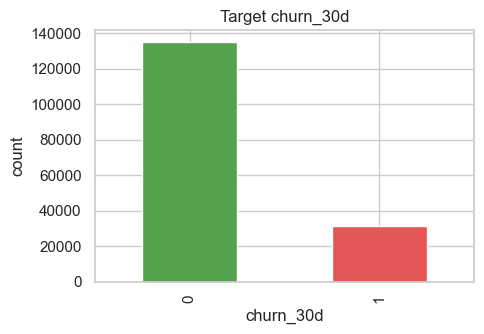

In [12]:
print("shape", processed.shape)
print("customers", processed["customer_id"].nunique())
print("months", processed["snapshot_month_ord"].nunique())
print("\nchurn_30d rate", processed[TARGET].mean().round(4))
print(processed[TARGET].value_counts(normalize=True).rename("share").round(4))

fig, ax = plt.subplots(figsize=(5, 3.5))
processed[TARGET].value_counts().sort_index().plot(kind="bar", ax=ax, color=["#54A24B", "#E45756"])
ax.set_title("Target churn_30d")
ax.set_xlabel(TARGET)
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

### 7.2. Missing: so sánh raw vs processed

In [14]:
cmp = pd.DataFrame({
    "raw_pct_missing": (raw.isna().mean() * 100).round(2),
})
# map snapshot_month → snapshot_month_ord cho so sánh thô
proc_miss = (processed.isna().mean() * 100).round(2)
cmp = cmp.join(proc_miss.rename("processed_pct_missing"), how="outer").fillna(0)
cmp = cmp.loc[(cmp["raw_pct_missing"] > 0) | (cmp.index.isin(miss_before.index))]
cmp = cmp.sort_values("raw_pct_missing", ascending=False)
print("Processed missing total:", int(processed.isna().sum().sum()))
cmp.head(20)

Processed missing total: 0


,raw_pct_missing,processed_pct_missing
session_duration_trend,80.14,0.0
avg_csat_score,78.20,0.0
open_rate_30d,41.63,0.0
payments_success_rate,25.22,0.0
auto_renew,8.52,0.0
subscription_tier,8.52,0.0
num_usage_events_30d_lag1m,5.85,0.0
days_since_last_activity_lag1m,5.85,0.0


### 7.3. Mô tả thống kê feature numeric

In [15]:
feature_cols = [c for c in processed.columns if c not in {"customer_id", TARGET}]
desc = processed[feature_cols].describe().T
desc["missing_pct"] = 0.0
desc.head(25)

,count,mean,std,min,25%,50%,75%,max,missing_pct
snapshot_month_ord,166084.0,24305.812842,8.181964e+00,24283.0,24300.000000,24307.000000,2.431300e+04,24317.0,0.0
activity_slope_3m,166084.0,0.737308,2.797965e+00,-36.0,0.000000,0.000000,0.000000e+00,36.0,0.0
age,166084.0,40.052245,1.361688e+01,15.0,28.300000,39.900000,5.180000e+01,64.8,0.0
auto_renew,166084.0,0.688820,6.202587e-01,-1.0,1.000000,1.000000,1.000000e+00,1.0,0.0
avg_csat_score,166084.0,3.492797,4.459057e-01,1.0,3.500000,3.500000,3.500000e+00,5.0,0.0
avg_csat_score_missing,166084.0,0.781990,4.128956e-01,0.0,1.000000,1.000000,1.000000e+00,1.0,0.0
avg_session_duration_30d,166084.0,233.410593,4.087614e+02,0.0,0.000000,0.000000,5.392714e+02,1799.0,0.0
avg_session_duration_roll3m_mean,166084.0,199.740581,3.532374e+02,0.0,0.000000,0.000000,2.964698e+02,1795.0,0.0
avg_spend_to_date_per_month,166084.0,958494.262650,1.124898e+06,0.0,193756.148296,655148.212729,1.329231e+06,22174000.0,0.0
city,166084.0,6.987482,4.317176e+00,0.0,3.000000,7.000000,1.100000e+01,14.0,0.0


### 7.4. Tương quan với `churn_30d` (top |corr|)

is_paid_tier                       -0.4064
subscription_tier                  -0.2721
avg_session_duration_30d           -0.2401
event_type_diversity_30d           -0.2373
total_active_days_30d              -0.2344
avg_session_duration_roll3m_mean   -0.2265
total_active_days_60d              -0.2262
num_usage_events_30d               -0.2253
total_session_time_30d             -0.2225
total_active_days_90d              -0.2176
num_usage_events_60d               -0.2164
snapshot_month_ord                 -0.2124
num_usage_events_roll3m_sum        -0.2073
session_duration_trend_missing      0.2028
num_usage_events_30d_lag1m         -0.1804
activity_slope_3m                  -0.1359
auto_renew                          0.1249
days_since_last_usage_event         0.1230
tenure_days                        -0.1199
days_since_last_login               0.1112


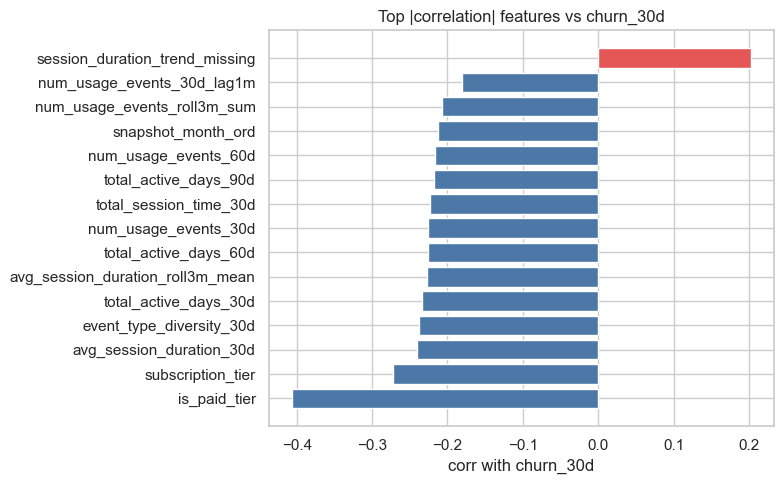

In [ ]:
corr_y = processed[feature_cols + [TARGET]].corr(numeric_only=True)[TARGET].drop(TARGET)
corr_y = corr_y.reindex(corr_y.abs().sort_values(ascending=False).index)
print(corr_y.head(20).round(4).to_string())

top = corr_y.head(15).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top.index, top.values, color=np.where(top.values >= 0, "#E45756", "#4C78A8"))
ax.set_xlabel(f"corr with {TARGET}")
ax.set_title("Top |correlation| features vs churn_30d")
plt.tight_layout()
plt.show()

### 7.5. Phân bố vài feature quan trọng theo churn

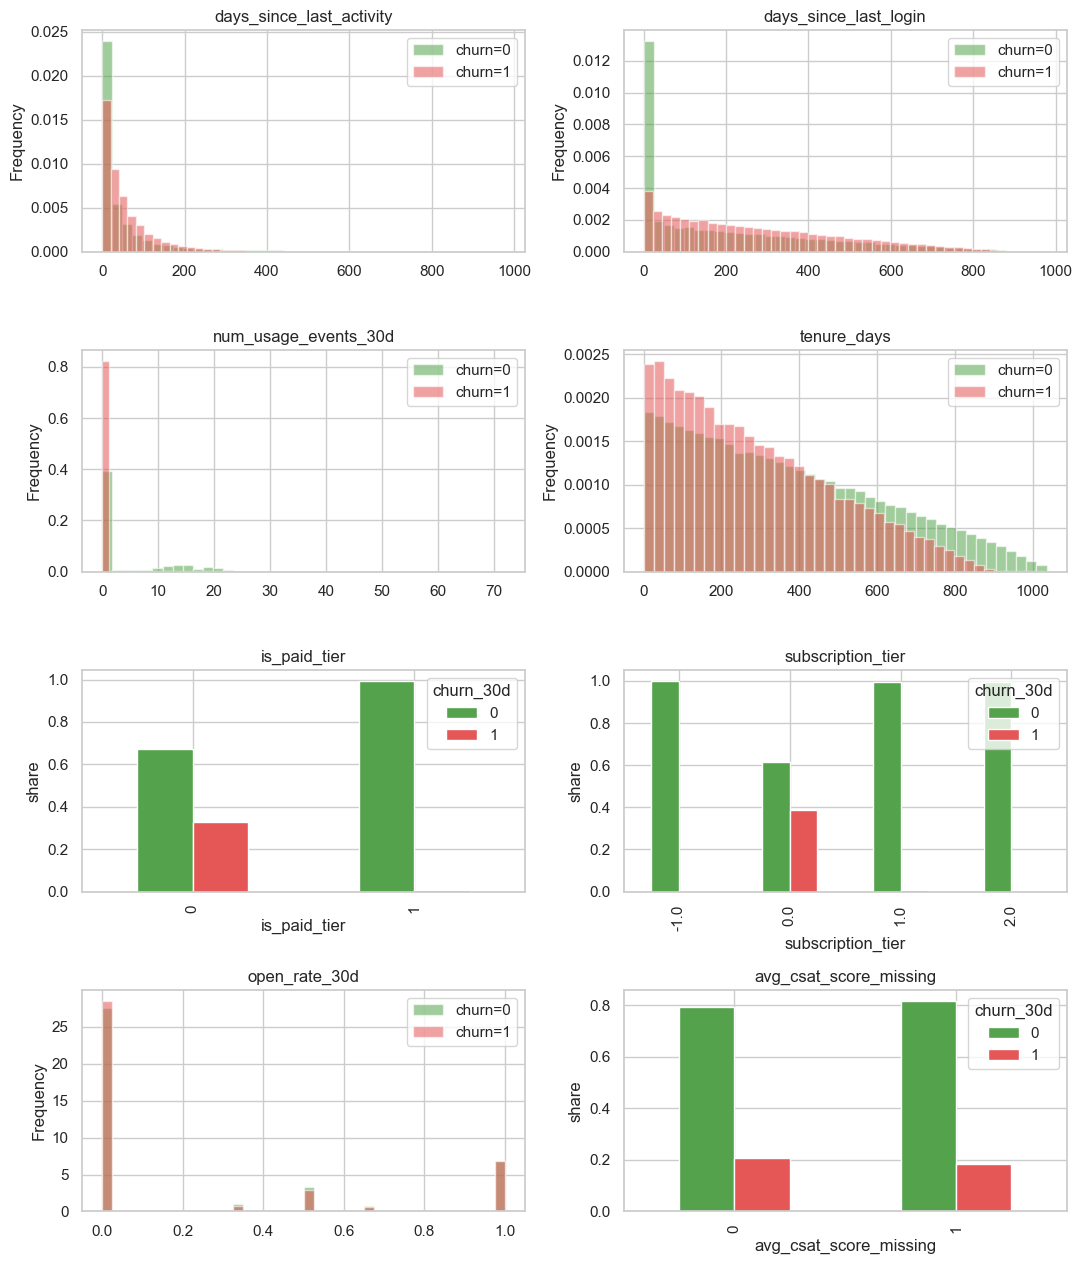

In [17]:
plot_cols = [
    c for c in [
        "days_since_last_activity",
        "days_since_last_login",
        "num_usage_events_30d",
        "tenure_days",
        "is_paid_tier",
        "subscription_tier",
        "open_rate_30d",
        "avg_csat_score_missing",
    ]
    if c in processed.columns
]

n = len(plot_cols)
ncols = 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(11, 3.2 * nrows))
axes = np.ravel(axes)
for ax, col in zip(axes, plot_cols):
    if processed[col].nunique() <= 6:
        tmp = processed.groupby([col, TARGET]).size().unstack(TARGET, fill_value=0)
        tmp_pct = tmp.div(tmp.sum(axis=1), axis=0)
        tmp_pct.plot(kind="bar", ax=ax, color=["#54A24B", "#E45756"])
        ax.set_ylabel("share")
    else:
        for y, color in [(0, "#54A24B"), (1, "#E45756")]:
            processed.loc[processed[TARGET] == y, col].plot(
                kind="hist", bins=40, alpha=0.55, ax=ax, color=color, label=f"churn={y}", density=True
            )
        ax.legend()
    ax.set_title(col)
for ax in axes[n:]:
    ax.axis("off")
plt.tight_layout()
plt.show()

### 7.6. Correlation heatmap (subset feature mạnh)

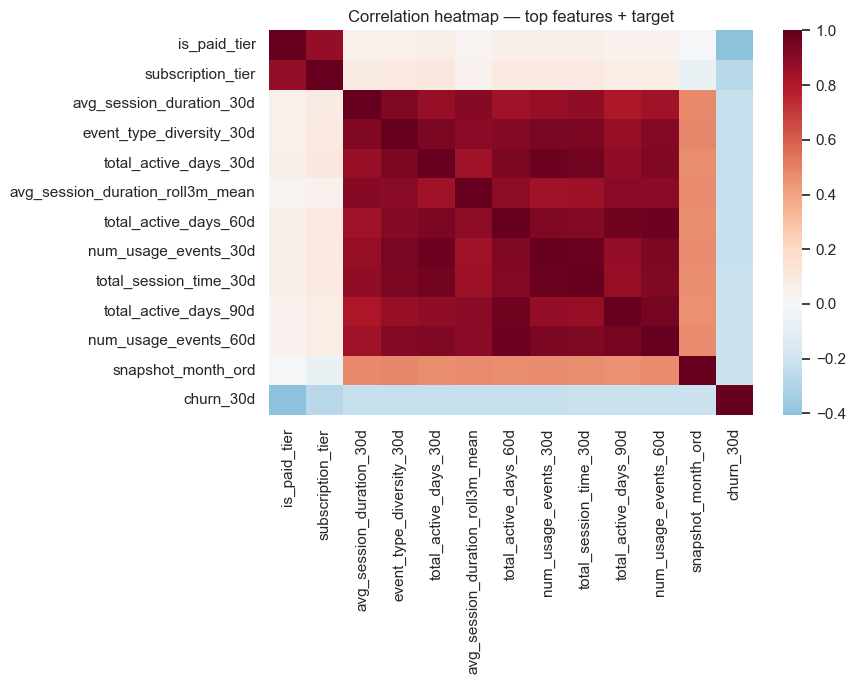

In [19]:
top_feats = corr_y.head(12).index.tolist()
heat_cols = top_feats + [TARGET]
corr_m = processed[heat_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_m, cmap="RdBu_r", center=0, ax=ax, fmt=".2f")
ax.set_title("Correlation heatmap — top features + target")
plt.tight_layout()
plt.show()

## 8. QA nhanh

In [20]:
assert processed.duplicated(["customer_id", "snapshot_month_ord"]).sum() == 0
assert processed[TARGET].isin([0, 1]).all()
assert processed.isna().sum().sum() == 0
assert all(pd.api.types.is_numeric_dtype(processed[c]) for c in processed.columns)
print("QA ok")
print("processed columns:")
print("\n".join(processed.columns.tolist()))

QA ok
processed columns:
customer_id
snapshot_month_ord
churn_30d
activity_slope_3m
age
auto_renew
avg_csat_score
avg_csat_score_missing
avg_session_duration_30d
avg_session_duration_roll3m_mean
avg_spend_to_date_per_month
city
days_since_last_activity
days_since_last_activity_lag1m
days_since_last_login
days_since_last_usage_event
event_type_diversity_30d
gender
has_marketing_click_30d
has_unresolved_ticket
is_declining_engagement
is_paid_tier
num_tickets_90d
num_usage_events_30d
num_usage_events_30d_lag1m
num_usage_events_60d
num_usage_events_roll3m_sum
open_rate_30d
orders_last_30d
orders_last_90d
orders_roll3m_sum
payments_success_rate
payments_success_rate_missing
reactivation_flag
region
session_duration_trend
session_duration_trend_missing
subscription_tier
tenure_days
total_active_days_30d
total_active_days_60d
total_active_days_90d
total_session_time_30d
usage_trend_30d
